<a href="https://colab.research.google.com/github/jegillis323/MAT-422/blob/main/MAT422_Section_1_4_SVD_Low_Rank_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.4: SVD, Low-Rank Approximation, and PCA

**Topics:** singular value decomposition, low-rank matrix approximations, principal component analysis

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition

Singular value decomposition factors a matrix A into A = U Sigma V^T. The columns of U and V are orthonormal directions, and the singular values in Sigma measure how much each direction contributes to the matrix.

In [3]:
A = np.array([
    [3, 2, 2],
    [2, 3, -2],
    [1, 1, 0],
    [0, 2, 1],
], dtype=float)

U_A, s_A, Vt_A = np.linalg.svd(A, full_matrices=False)
Sigma_A = np.diag(s_A)
A_reconstructed = U_A @ Sigma_A @ Vt_A

B = np.array([
    [5, 6, 1],
    [9, 2, 4],
    [1, 2, 6],
    [4, 8, 3]
], dtype=float)

U_B, s_B, Vt_B = np.linalg.svd(B, full_matrices=False)
Sigma_B = np.diag(s_B)
B_reconstructed = U_B @ Sigma_B @ Vt_B

print("A =")
print(A)
print("\nSingular values =", s_A)
print("\nU shape, Sigma shape, Vt shape =", U_A.shape, Sigma_A.shape, Vt_A.shape)
print("\nU.T @ U =")
print(U_A.T @ U_A)
print("\nVt @ Vt.T =")
print(Vt_A @ Vt_A.T)
print("\nReconstruction error ||A - U Sigma Vt||_F =", np.linalg.norm(A - A_reconstructed, ord="fro"))
print("Reconstruction is accurate?", np.allclose(A, A_reconstructed))

print("\n\nB =")
print(B)
print("\nSingular values =", s_B)
print("\nU shape, Sigma shape, Vt shape =", U_B.shape, Sigma_B.shape, Vt_B.shape)
print("\nU.T @ U =")
print(U_B.T @ U_B)
print("\nVt @ Vt.T =")
print(Vt_B @ Vt_B.T)
print("\nReconstruction error ||B - U Sigma Vt||_F =", np.linalg.norm(B - B_reconstructed, ord="fro"))
print("Reconstruction is accurate?", np.allclose(B, B_reconstructed))

A =
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]

Singular values = [5.4071 3.0452 1.5779]

U shape, Sigma shape, Vt shape = (4, 3) (3, 3) (3, 3)

U.T @ U =
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

Vt @ Vt.T =
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Reconstruction error ||A - U Sigma Vt||_F = 5.375046761694035e-15
Reconstruction is accurate? True


B =
[[5. 6. 1.]
 [9. 2. 4.]
 [1. 2. 6.]
 [4. 8. 3.]]

Singular values = [15.2584  5.8396  5.1071]

U shape, Sigma shape, Vt shape = (4, 3) (3, 3) (3, 3)

U.T @ U =
[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

Vt @ Vt.T =
[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]

Reconstruction error ||B - U Sigma Vt||_F = 7.136584070361083e-15
Reconstruction is accurate? True


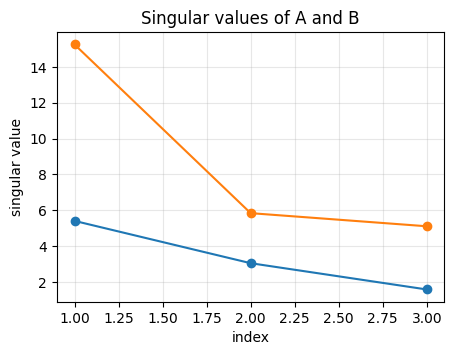

In [6]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(s_A) + 1), s_A, marker="o")
plt.plot(np.arange(1, len(s_B) + 1), s_B, marker="o")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of A and B")
plt.grid(True, alpha=0.3)
plt.show()


Large singular values indicate directions that carry more structure. Smaller singular values contribute less, which is why SVD is useful for approximation and compression.

My Explanation: Singular Value Decomposition (SVD), factors a matrix into $U, \Sigma,$ and $V^T$, where $U$ contains the orthonormal vectors that describe the direction of the output, $\Sigma$ is a diagonal matrix of the singular values, which tells how much the matrix stretches or compresses the space, and $V^T$ contains the orthonormal vectors that describe the direction of the input. This decomposition is important because it can work for any matrix, not just square matrices. This means that any size matrix can be approximated into the singular values without losing important information.

## 1.4.2 Low-Rank Matrix Approximations

A rank-k approximation keeps only the first k singular values and singular vectors. This gives a simpler matrix A_k that captures the strongest patterns in A.

In [12]:
def rank_k_approximation_A(U, s_A, Vt, k):
    return U[:, :k] @ np.diag(s_A[:k]) @ Vt[:k, :]

errors_A = []
for k in range(1, len(s_A) + 1):
    A_k = rank_k_approximation_A(U_A, s_A, Vt_A, k)
    error_A = np.linalg.norm(A - A_k, ord="fro")
    errors_A.append(error_A)
    print(f"Rank-{k} approximation for A:")
    print(A_k)
    print("Frobenius error =", error_A)
    print("matrix rank =", np.linalg.matrix_rank(A_k))
    print()

def rank_k_approximation_B(U, s_B, Vt, k):
    return U[:, :k] @ np.diag(s_B[:k]) @ Vt[:k, :]

errors_B = []
for k in range(1, len(s_B) + 1):
    B_k = rank_k_approximation_B(U_B, s_B, Vt_B, k)
    error_B = np.linalg.norm(B - B_k, ord="fro")
    errors_B.append(error_B)
    print(f"Rank-{k} approximation for B:")
    print(B_k)
    print("Frobenius error =", error_B)
    print("matrix rank =", np.linalg.matrix_rank(B_k))
    print()

Rank-1 approximation for A:
[[2.3471 2.7154 0.232 ]
 [2.2456 2.5979 0.2219]
 [0.9185 1.0627 0.0908]
 [1.0274 1.1886 0.1015]]
Frobenius error = 3.4297069364073947
matrix rank = 1

Rank-2 approximation for A:
[[ 2.6053  2.3309  2.1213]
 [ 1.9444  3.0466 -1.9829]
 [ 0.9099  1.0755  0.0277]
 [ 1.1039  1.0748  0.6609]]
Frobenius error = 1.577861346829626
matrix rank = 2

Rank-3 approximation for A:
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]
Frobenius error = 5.375046761694035e-15
matrix rank = 3

Rank-1 approximation for B:
[[5.0463 4.5465 3.0738]
 [6.065  5.4643 3.6943]
 [2.958  2.6651 1.8018]
 [5.9718 5.3804 3.6376]]
Frobenius error = 7.757753825756814
matrix rank = 1

Rank-2 approximation for B:
[[4.091  5.9902 2.5068]
 [8.362  1.9931 5.0575]
 [3.3812 2.0256 2.0529]
 [4.2366 8.0025 2.6078]]
Frobenius error = 5.107090510161877
matrix rank = 2

Rank-3 approximation for B:
[[5. 6. 1.]
 [9. 2. 4.]
 [1. 2. 6.]
 [4. 8. 3.]]
Frobenius error = 7.136584070361083e-15
matrix rank 

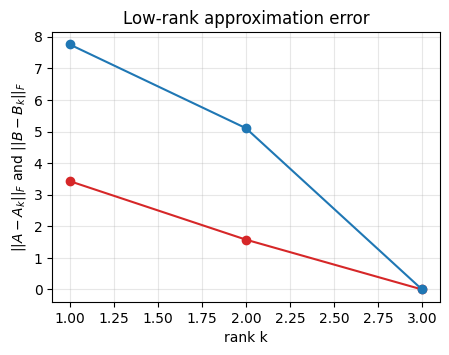

In [16]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(errors_A) + 1), errors_A, marker="o", color="tab:red")
plt.plot(np.arange(1, len(errors_B)+ 1), errors_B, marker="o", color="tab:blue")
plt.xlabel("rank k")
plt.ylabel("$||A-A_k||_F$ and $||B-B_k||_F$")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()

The approximation error decreases as k increases. When k reaches the full rank, the approximation becomes the original matrix up to numerical roundoff.

My Explanation: Low Rank Matrix Approximation takes the singular values from $\Sigma$ from the SVD and approximates it by taking a certain $k$ number of singular values. As the graph shows, the more singular values that are considered decrease the error but means that more of the matrix is being considered. If the later singular values are less impactful than the earlier ones, Low Rank Matrix Approximation can be useful in condensing the information so that only the most impactful vectors are being considered.

## 1.4.3 Principal Component Analysis

Principal component analysis finds directions of maximum variation in centered data. PCA can be computed using SVD: after centering the data matrix X, the rows of V^T give principal component directions.

In [20]:
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9],
], dtype=float)

Y = np.array([
    [1.7, 2.6],
    [2.3, 3.1],
    [0.1, 2.8],
    [1.4, 3.4],
    [2.5, 1.5],
    [0.5, 2.3],
    [1.2, 0.2],
    [1.7, 0.3],
    [1.2, 2.1],
    [3.0, 0.9],
], dtype=float)

mean_X = X.mean(axis=0)
X_centered = X - mean_X
U_pca_X, s_pca_X, Vt_pca_X = np.linalg.svd(X_centered, full_matrices=False)
scores_X = X_centered @ Vt_pca_X.T
explained_variance_X = (s_pca_X**2) / (len(X) - 1)
explained_ratio_X = explained_variance_X / explained_variance_X.sum()

mean_Y = Y.mean(axis=0)
Y_centered = Y - mean_Y
U_pca_Y, s_pca_Y, Vt_pca_Y = np.linalg.svd(Y_centered, full_matrices=False)
scores_Y = Y_centered @ Vt_pca_Y.T
explained_variance_Y = (s_pca_Y**2) / (len(Y) - 1)
explained_ratio_Y = explained_variance_Y / explained_variance_Y.sum()

print("feature means =", mean_X)
print("principal directions as rows of Vt =")
print(Vt_pca_X)
print("singular values =", s_pca_X)
print("explained variance =", explained_variance_X)
print("explained variance ratio =", explained_ratio_X)
print("first three PCA scores =")
print(scores_X[:3])

print("\n\nfeature means =", mean_Y)
print("principal directions as rows of Vt =")
print(Vt_pca_Y)
print("singular values =", s_pca_Y)
print("explained variance =", explained_variance_Y)
print("explained variance ratio =", explained_ratio_Y)
print("first three PCA scores =")
print(scores_Y[:3])

feature means = [1.81 1.91]
principal directions as rows of Vt =
[[-0.6779 -0.7352]
 [ 0.7352 -0.6779]]
singular values = [3.3994 0.6646]
explained variance = [1.284  0.0491]
explained variance ratio = [0.9632 0.0368]
first three PCA scores =
[[-0.828   0.1751]
 [ 1.7776 -0.1429]
 [-0.9922 -0.3844]]


feature means = [1.56 1.92]
principal directions as rows of Vt =
[[ 0.3956 -0.9184]
 [ 0.9184  0.3956]]
singular values = [3.5874 2.4517]
explained variance = [1.4299 0.6678]
explained variance ratio = [0.6816 0.3184]
first three PCA scores =
[[-0.5691  0.3976]
 [-0.791   1.1464]
 [-1.3858 -0.9928]]


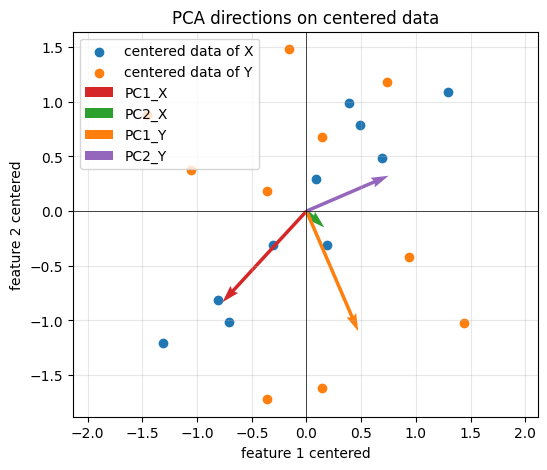

In [23]:
origin = np.zeros(2)
pc1_X = Vt_pca_X[0] * s_pca_X[0] / np.sqrt(len(X) - 1)
pc2_X = Vt_pca_X[1] * s_pca_X[1] / np.sqrt(len(X) - 1)
pc1_Y = Vt_pca_Y[0] * s_pca_Y[0] / np.sqrt(len(Y) - 1)
pc2_Y = Vt_pca_Y[1] * s_pca_Y[1] / np.sqrt(len(Y) - 1)

plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data of X")
plt.scatter(Y_centered[:, 0], Y_centered[:, 1], color="tab:orange", label="centered data of Y")
plt.quiver(*origin, *pc1_X, angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1_X")
plt.quiver(*origin, *pc2_X, angles="xy", scale_units="xy", scale=1, color="tab:green", label="PC2_X")
plt.quiver(*origin, *pc1_Y, angles="xy", scale_units="xy", scale=1, color="tab:orange", label="PC1_Y")
plt.quiver(*origin, *pc2_Y, angles="xy", scale_units="xy", scale=1, color="tab:purple", label="PC2_Y")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1 centered")
plt.ylabel("feature 2 centered")
plt.title("PCA directions on centered data")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

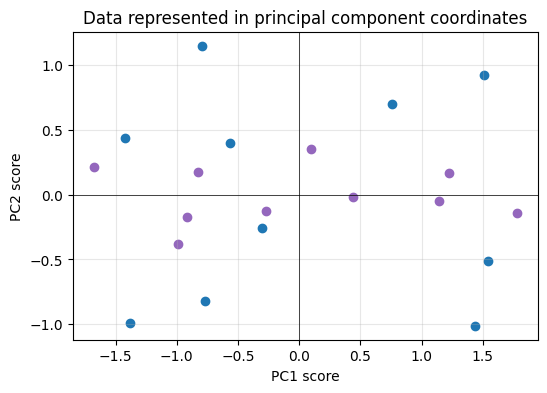

In [24]:
plt.figure(figsize=(6, 4))
plt.scatter(scores_X[:, 0], scores_X[:, 1], color="tab:purple")
plt.scatter(scores_Y[:, 0], scores_Y[:, 1], color="tab:blue")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Data represented in principal component coordinates")
plt.grid(True, alpha=0.3)
plt.show()

The first principal component explains the largest share of variance. Projecting data onto PC1 and PC2 rotates the coordinate system so the strongest variation appears along the first axis.

My Explanation: Principle Component Analysis (PCA) finds new directions, also called principle components, that have the greatest variation in the data. With matrices, there can be many variables, so principle components can be used to accurately describe the data while cutting down on the amount of variables there are. The first principle component (PC1) gives the direction that the data varies the most. The second principle component (PC2) is orthogonal to PC1 and captures the greatest amount of variation. If there were more principle components afterward, they would continue to capture more and more of the remaining variation while staying orthogonal to the previous compenent. PCA can be nice to reduce the amount of variables that are used in a scenario, especially if only a few provide a large amount of the variation.   

## Reflection and Rubric Checklist

- Code Accuracy and Completeness: I ran the notebook from top to bottom without errors.
- Math Concept Coverage: I demonstrated SVD, low-rank approximation, and PCA.
- Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- Explanation and Documentation: I explained the purpose and meaning of each code section.
- GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- Personalization: I changed or extended at least one example so the notebook reflects my own work.